In [ ]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point

# Load data
df = pd.read_csv('/content/Crimes_-_2001_to_Present_20251023.csv')

# Drop rows without coordinates
df = df.dropna(subset=['Latitude', 'Longitude'])

# Convert to GeoDataFrame
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df['Longitude'], df['Latitude']),
    crs="EPSG:4326"
)

# Replace path with your downloaded file
communities = gpd.read_file("/content/Boundaries_-_Community_Areas_20251023.geojson")

# Ensure both have same CRS
gdf = gdf.set_crs("EPSG:4326")
communities = communities.to_crs("EPSG:4326")

# Spatial join
gdf_joined = gpd.sjoin(gdf, communities, how="inner", predicate="within")



In [ ]:
gdf_joined["Date"] = pd.to_datetime(gdf_joined["Date"], errors="coerce")
gdf_joined["Month"] = gdf_joined["Date"].dt.month_name()
gdf_joined["DayOfWeek"] = gdf_joined["Date"].dt.day_name()
gdf_joined["Hour"] = gdf_joined["Date"].dt.hour


/tmp/ipython-input-1584320781.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  gdf_joined["Date"] = pd.to_datetime(gdf_joined["Date"], errors="coerce")


In [ ]:
print(gdf_joined.head())
print(gdf_joined.info())


         ID Case Number       Date                  Block  IUCR  \
0  13998259    JJ452257 2025-10-15      035XX S HONORE ST  1320   
1  13999795    JJ454236 2025-10-15      060XX S BISHOP ST  1153   
2  14000982    JJ454683 2025-10-15       009XX W HURON ST  1320   
3  13998239    JJ452250 2025-10-15        023XX E 70TH ST  0810   
4  13998902    JJ453006 2025-10-15  080XX S FRANCISCO AVE  1544   

         Primary Type                          Description  \
0     CRIMINAL DAMAGE                           TO VEHICLE   
1  DECEPTIVE PRACTICE  FINANCIAL IDENTITY THEFT OVER $ 300   
2     CRIMINAL DAMAGE                           TO VEHICLE   
3               THEFT                            OVER $500   
4         SEX OFFENSE       SEXUAL EXPLOITATION OF A CHILD   

              Location Description  Arrest  Domestic  ...  \
0  RESIDENCE - YARD (FRONT / BACK)   False     False  ...   
1                        RESIDENCE   False     False  ...   
2                           STREET   Fals

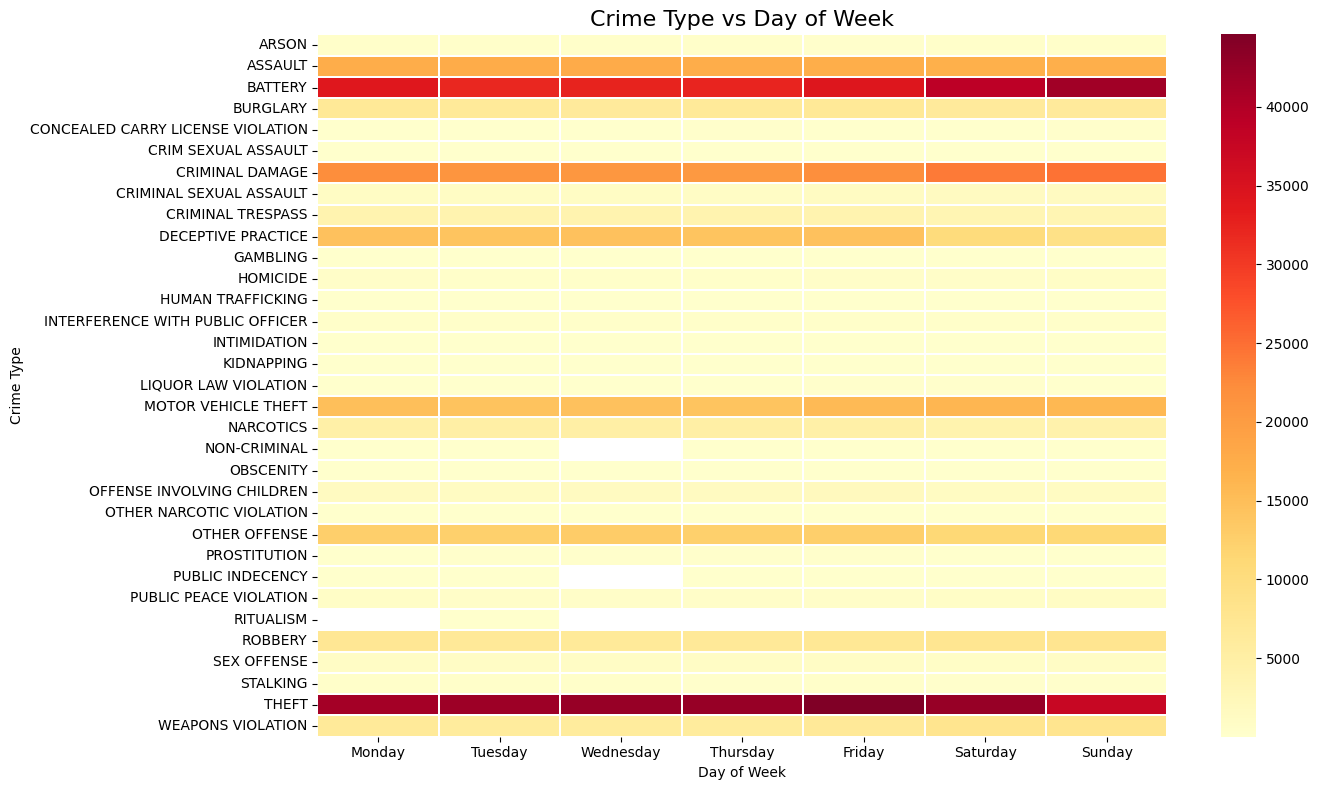

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Aggregate counts
dow_type = (
    gdf_joined
    .groupby(["DayOfWeek", "Primary Type"])["ID"]
    .count()
    .reset_index()
)

# Reorder days
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
pivot = dow_type.pivot(index="Primary Type", columns="DayOfWeek", values="ID")[order]

plt.figure(figsize=(14, 8))
sns.heatmap(pivot, cmap="YlOrRd", linewidths=0.3)
plt.title("Crime Type vs Day of Week", fontsize=16)
plt.xlabel("Day of Week")
plt.ylabel("Crime Type")
plt.tight_layout()
plt.show()


In [ ]:
import plotly.express as px
import pandas as pd

# Ensure date column is datetime
gdf_joined["Date"] = pd.to_datetime(gdf_joined["Date"], errors="coerce")

# Extract month name
gdf_joined["Month"] = gdf_joined["Date"].dt.month_name()

# Define month order
month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

# Filter for top 10 crime types
top10_crimes = gdf_joined["Primary Type"].value_counts().nlargest(10).index
subset = gdf_joined[gdf_joined["Primary Type"].isin(top10_crimes)]

# Group by month and crime type (aggregating across all years)
month_type = (
    subset
    .groupby(["Month", "Primary Type"])["ID"]
    .count()
    .reset_index()
)

# Sort months chronologically
month_type["Month"] = pd.Categorical(month_type["Month"], categories=month_order, ordered=True)
month_type = month_type.sort_values("Month")

# Plot the aggregated time series
fig = px.line(
    month_type,
    x="Month",
    y="ID",
    color="Primary Type",
    title="Seasonal Trends of Top 10 Crime Types (Aggregated Across Years)",
    markers=True,
    category_orders={"Month": month_order},
    height=600
)

fig.update_layout(
    xaxis_title="Month",
    yaxis_title="Total Crimes",
    legend_title="Crime Type",
    hovermode="x unified"
)

fig.show()


In [ ]:
import plotly.express as px
import pandas as pd

# Top 10 crimes
top10_crimes = gdf_joined["Primary Type"].value_counts().nlargest(10).index

# Hourly distribution
hourly_top10 = (
    gdf_joined[gdf_joined["Primary Type"].isin(top10_crimes)]
    .groupby(["Hour", "Primary Type"])["ID"]
    .count()
    .reset_index()
)

# Find the peak hour for each crime
peak_hours = (
    hourly_top10.loc[hourly_top10.groupby("Primary Type")["ID"].idxmax()]
    .reset_index(drop=True)
)

# Base line chart
fig = px.line(
    hourly_top10,
    x="Hour",
    y="ID",
    color="Primary Type",
    title="Hourly Patterns of Top 10 Crime Types (with Peak Hours)",
    height=600
)

# Add scatter markers for peak points
fig.add_scatter(
    x=peak_hours["Hour"],
    y=peak_hours["ID"],
    mode="markers+text",
    text=peak_hours["Primary Type"],
    textposition="top center",
    marker=dict(size=10, color="black", symbol="x"),
    name="Peak Hour"
)

fig.update_xaxes(dtick=1)
fig.update_layout(legend_title_text="Crime Type")
fig.show()


In [ ]:
import plotly.express as px
import pandas as pd

# Ensure 'Date' is datetime
gdf_joined["Date"] = pd.to_datetime(gdf_joined["Date"], errors="coerce")

# Extract month name
gdf_joined["Month"] = gdf_joined["Date"].dt.month_name()

# Define month order
month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

# Top 10 crimes
top10_crimes = gdf_joined["Primary Type"].value_counts().nlargest(10).index

# Filter dataset
subset = gdf_joined[gdf_joined["Primary Type"].isin(top10_crimes)]

# Aggregate by month and crime type
heatmap_data = (
    subset
    .groupby(["Primary Type", "Month"])["ID"]
    .count()
    .reset_index()
)

# Ensure chronological months
heatmap_data["Month"] = pd.Categorical(heatmap_data["Month"], categories=month_order, ordered=True)
heatmap_data = heatmap_data.sort_values("Month")

# 🔹 Normalize counts per crime type (0–1 scale)
heatmap_data["Normalized"] = (
    heatmap_data.groupby("Primary Type")["ID"]
    .transform(lambda x: x / x.max())
)

# Plot normalized heatmap
fig = px.imshow(
    heatmap_data.pivot(index="Primary Type", columns="Month", values="Normalized"),
    color_continuous_scale="Reds",
    title="Normalized Heatmap of Monthly Crime Seasonality (Top 10 Crime Types)",
    aspect="auto",
    height=600
)

# Improve layout
fig.update_layout(
    xaxis_title="Month",
    yaxis_title="Crime Type",
    coloraxis_colorbar_title="Relative Intensity",
)

fig.show()


# Insights

## Seasonalities of crime in Chicago
After this correlational analysis comparing primary crime types with the moment they are commited on (day of the week, month, hour of the day). We can draw some sensible conclusions about seasonality.
- Multiple crime peaks around the month of July: This could be due to various reasons, including a height of people outdoors making all types of interactions more frequent or summer's heat making people more aggressive.
- Most crimes peak at around midnight: This makes sense considering that usually it's less likely to be caught committing a crime in the middle of the night.
- Some crimes are more frequent in different months: Robbery and Deceptive Practices are abnormally frequent in the months of December-January, which could be explained by the economic strain of those months (holiday shopping and January's financial strain).

## Recommendations:
- Reinforce patrolling around midnight.
- Allocate more budget to security around summer season (May - October).
- Strategically manage security around holiday season to look for more frequent crimes (Robbery and Deceptive Practices).  